In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, roc_auc_score)

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

print("Loading Dataset...")

df = pd.read_csv('/content/drive/MyDrive/multiclass_loan_prediction_dataset.csv')
df.columns = df.columns.str.strip()

print("Shape   :", df.shape)
print("Columns :", list(df.columns))
print(df.head())

Loading Dataset...
Shape   : (5000, 7)
Columns : ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Status']
   Age  Income  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0   56   21920           454        38523         60          Employed   
1   69  126121           389        36889         36     Self-Employed   
2   46   97219           657        30465         24          Employed   
3   32   96872           473        35593         36     Self-Employed   
4   60  101132           516        26330         12     Self-Employed   

           Loan_Status  
0             Rejected  
1             Rejected  
2  Approved - Standard  
3             Rejected  
4             Rejected  


In [ ]:
import warnings


target = 'Loan_Status'


label_encoder = LabelEncoder()


if df[target].dtype == object:
    df[target] = label_encoder.fit_transform(df[target])


original_class_names = label_encoder.classes_

print(f"Target column : '{target}'")
print("Class Distribution (Numerical Labels):")
print(df[target].value_counts())
print("Original Class Names and their mapped numerical labels:")
for i, name in enumerate(original_class_names):
    print(f"  {name} -> {i}")

warnings.filterwarnings('ignore', category=UserWarning, module='seaborn')


Target column : 'Loan_Status'
Class Distribution (Numerical Labels):
Loan_Status
2    2258
3    1161
1    1143
0     438
Name: count, dtype: int64
Original Class Names and their mapped numerical labels:
  Approved - Premium -> 0
  Approved - Standard -> 1
  Rejected -> 2
  Under Review -> 3


Generating EDA Plots...


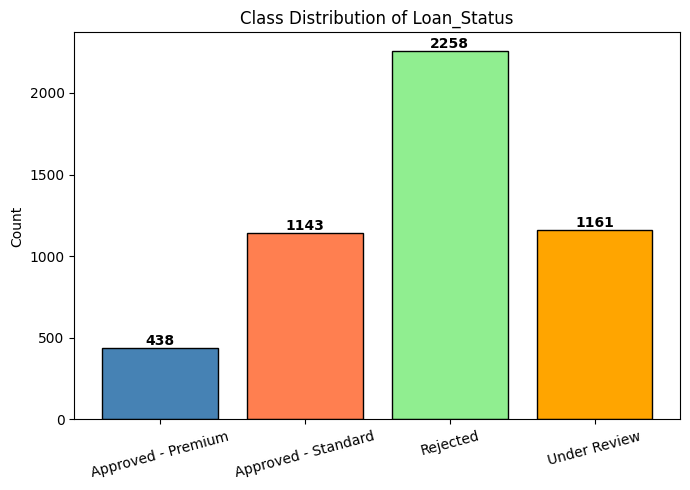

Saved: plot1_class_distribution.png


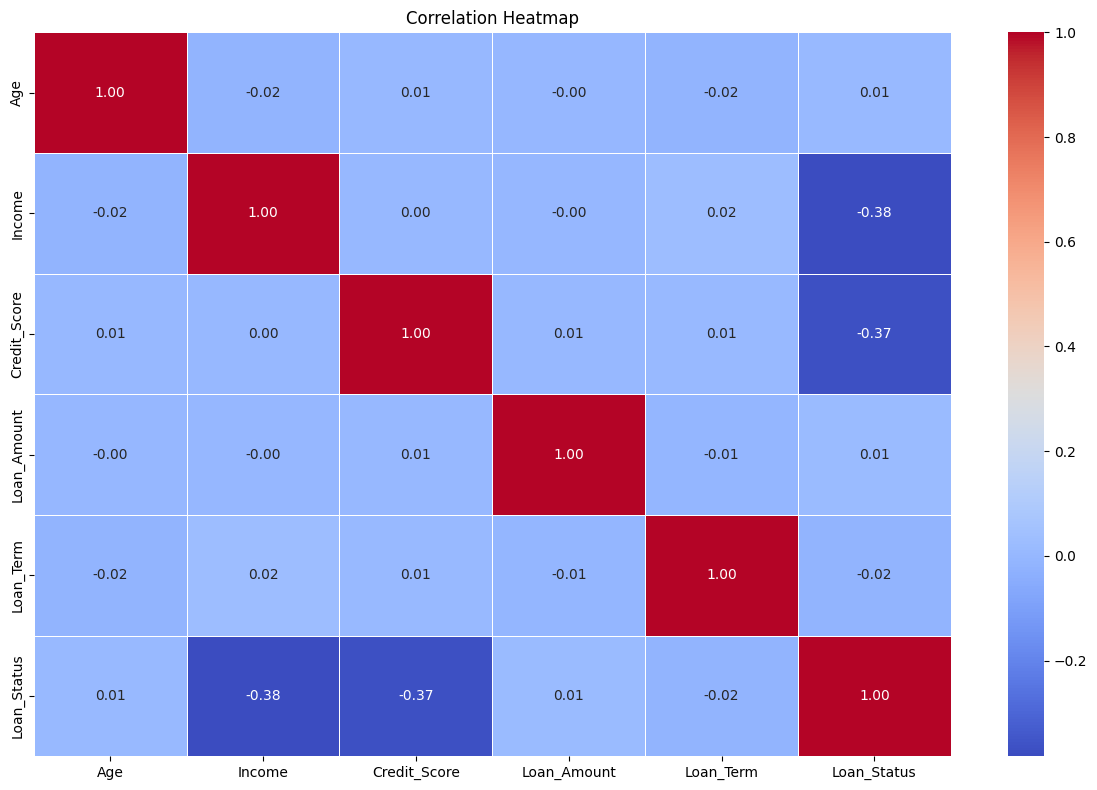

Saved: plot2_correlation_heatmap.png


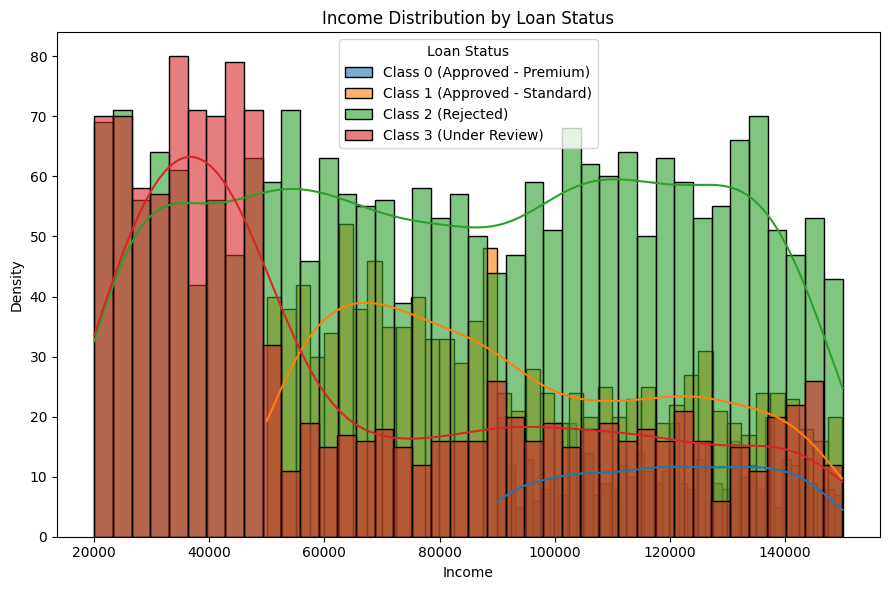

Saved: plot3_income_by_loan_status.png


In [ ]:

print("Generating EDA Plots...")


plt.figure(figsize=(7, 5))
counts = df[target].value_counts().sort_index()

class_labels_for_plot = [original_class_names[i] for i in counts.index]
plt.bar(class_labels_for_plot, counts.values,
        color=['steelblue', 'coral', 'lightgreen', 'orange', 'purple'][:len(class_labels_for_plot)],
        edgecolor='black')
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.title('Class Distribution of Loan_Status')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plot1_class_distribution.png')
plt.show()
print("Saved: plot1_class_distribution.png")


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png')
plt.show()
print("Saved: plot2_correlation_heatmap.png")


plt.figure(figsize=(9, 6))
for val in sorted(df[target].unique()):

    class_name = original_class_names[val]
    sns.histplot(df[df[target] == val]['Income'], bins=40,
                 alpha=0.6, label=f'Class {val} ({class_name})', kde=True)
plt.title('Income Distribution by Loan Status')
plt.xlabel('Income')
plt.ylabel('Density')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.savefig('plot3_income_by_loan_status.png')
plt.show()
print("Saved: plot3_income_by_loan_status.png")


In [ ]:

print("Preprocessing...")


df.dropna(inplace=True)
print(f"Rows after dropping nulls: {len(df)}")


X = df.drop(columns=[target]) # Removed 'LoanID' as it's not in the dataset
y = df[target]


cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Encoding categorical columns: {cat_cols}")
X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=False) # drop_first=False is generally safer for multiclass features
print(f"Shape after encoding: {X_enc.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y)


MAX_ROWS = 40000
if len(X_train) > MAX_ROWS:
    print(f"Train set has {len(X_train)} rows — sampling {MAX_ROWS} rows")
    X_train, _, y_train, _ = train_test_split(
        X_train, y_train,
        train_size=MAX_ROWS,
        random_state=42,
        stratify=y_train)    # keeps class ratio in training


scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain rows : {len(X_train)}")
print(f"Test  rows : {len(X_test)}")
print("Train class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print("Test  class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("Preprocessing complete!")


Preprocessing...
Rows after dropping nulls: 5000
Encoding categorical columns: ['Employment_Status']
Shape after encoding: (5000, 8)

Train rows : 4000
Test  rows : 1000
Train class distribution:
Loan_Status
2    45.2%
3    23.2%
1    22.8%
0     8.8%
Name: proportion, dtype: object
Test  class distribution:
Loan_Status
2    45.1%
3    23.2%
1    22.9%
0     8.8%
Name: proportion, dtype: object
Preprocessing complete!


In [ ]:

print("Defining Models...")

models = {
    'Logistic (Base)':     LogisticRegression(
                               max_iter=1000, random_state=42,
                               class_weight='balanced'),

    'Logistic L1 (Lasso)': LogisticRegression(
                               penalty='l1', C=1.0, solver='liblinear',
                               max_iter=1000, random_state=42,
                               class_weight='balanced'),

    'Logistic L2 (Ridge)': LogisticRegression(
                               penalty='l2', C=1.0, solver='lbfgs',
                               max_iter=1000, random_state=42,
                               class_weight='balanced'),

    'Decision Tree':       DecisionTreeClassifier(
                               max_depth=6, random_state=42,
                               class_weight='balanced'),

    'Random Forest':       RandomForestClassifier(
                               n_estimators=50, max_depth=6,
                               random_state=42, n_jobs=-1,
                               class_weight='balanced'),

    'KNN':                 KNeighborsClassifier(
                               n_neighbors=5, n_jobs=-1),

    'Naive Bayes':         GaussianNB(),
}

for name in models:
    print(f"  • {name}")

Defining Models...
  • Logistic (Base)
  • Logistic L1 (Lasso)
  • Logistic L2 (Ridge)
  • Decision Tree
  • Random Forest
  • KNN
  • Naive Bayes


In [ ]:

print("Training & Evaluating All Models...")
print(f"\n{'Model':<22} {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'AUC':>8}")
print("-" * 58)

precision_scores = {}
recall_scores    = {}
f1_scores        = {}
auc_scores       = {}
all_preds        = {}
all_probas       = {}

# Determine the number of classes for multiclass metrics
n_classes = len(original_class_names)

for name, model in models.items():
    print(f"  Training {name}...", end=' ', flush=True)

    # Train
    model.fit(X_train, y_train)

    # Predict
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test) # probabilities for all classes


    prec    = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec     = recall_score(y_test, pred, average='weighted', zero_division=0)
    f1      = f1_score(y_test, pred, average='weighted', zero_division=0)


    if n_classes > 1:
        roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')
    else: # If by chance it becomes binary after some filtering
        roc_auc = roc_auc_score(y_test, proba[:, 1], multi_class='ovr', average='weighted')


    # Store
    precision_scores[name] = prec
    recall_scores[name]    = rec
    f1_scores[name]        = f1
    auc_scores[name]       = roc_auc
    all_preds[name]        = pred
    # Store full probabilities for potential individual class ROC curve plotting later
    all_probas[name]       = proba

    print(f"Done  ->  F1={f1:.4f}  AUC={roc_auc:.4f}")

# Print final table
print(f"\n{'Model':<22} {'Precision':>10}  {'Recall':>8}  {'F1':>8}  {'AUC':>8}")
print("-" * 58)
for name in models:
    print(f"{name:<22} {precision_scores[name]:>10.4f}  "\
          f"{recall_scores[name]:>8.4f}  {f1_scores[name]:>8.4f}  "\
          f"{auc_scores[name]:>8.4f}")


Training & Evaluating All Models...

Model                   Precision    Recall        F1       AUC
----------------------------------------------------------
  Training Logistic (Base)... Done  ->  F1=0.8536  AUC=0.9696
  Training Logistic L1 (Lasso)... Done  ->  F1=0.8223  AUC=0.9506
  Training Logistic L2 (Ridge)... Done  ->  F1=0.8536  AUC=0.9696
  Training Decision Tree... Done  ->  F1=1.0000  AUC=1.0000
  Training Random Forest... Done  ->  F1=1.0000  AUC=1.0000
  Training KNN... Done  ->  F1=0.8292  AUC=0.9621
  Training Naive Bayes... Done  ->  F1=0.7419  AUC=0.9232

Model                   Precision    Recall        F1       AUC
----------------------------------------------------------
Logistic (Base)            0.8563    0.8540    0.8536    0.9696
Logistic L1 (Lasso)        0.8228    0.8250    0.8223    0.9506
Logistic L2 (Ridge)        0.8563    0.8540    0.8536    0.9696
Decision Tree              1.0000    1.0000    1.0000    1.0000
Random Forest              1.0000    1

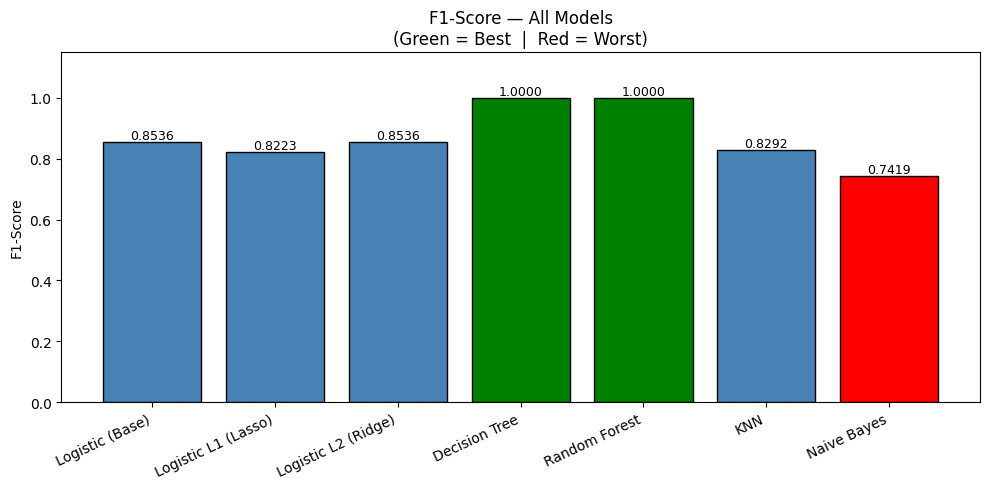

Saved: plot4_f1_bar.png


In [ ]:

plt.figure(figsize=(10, 5))
bar_colors = ['green' if v == max(f1_scores.values()) else
              'red'   if v == min(f1_scores.values()) else
              'steelblue' for v in f1_scores.values()]
bars = plt.bar(f1_scores.keys(), f1_scores.values(),
               color=bar_colors, edgecolor='black')
plt.title('F1-Score — All Models\n(Green = Best  |  Red = Worst)')
plt.ylabel('F1-Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=25, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.4f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot4_f1_bar.png')
plt.show()
print("Saved: plot4_f1_bar.png")

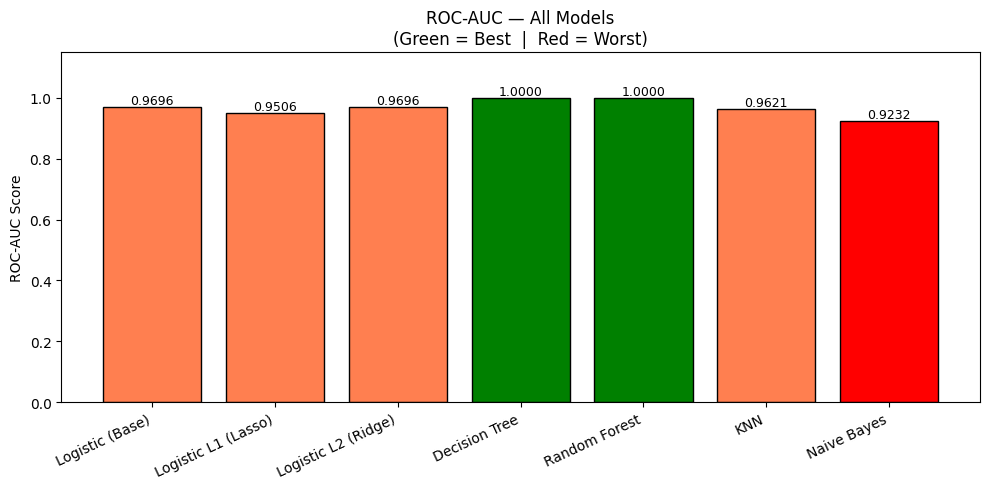

Saved: plot5_auc_bar.png


In [ ]:
plt.figure(figsize=(10, 5))
bar_colors_auc = ['green' if v == max(auc_scores.values()) else
                  'red'   if v == min(auc_scores.values()) else
                  'coral' for v in auc_scores.values()]
bars_auc = plt.bar(auc_scores.keys(), auc_scores.values(),
                   color=bar_colors_auc, edgecolor='black')
plt.title('ROC-AUC — All Models\n(Green = Best  |  Red = Worst)')
plt.ylabel('ROC-AUC Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=25, ha='right')
for bar in bars_auc:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.4f}',
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot5_auc_bar.png')
plt.show()
print("Saved: plot5_auc_bar.png")

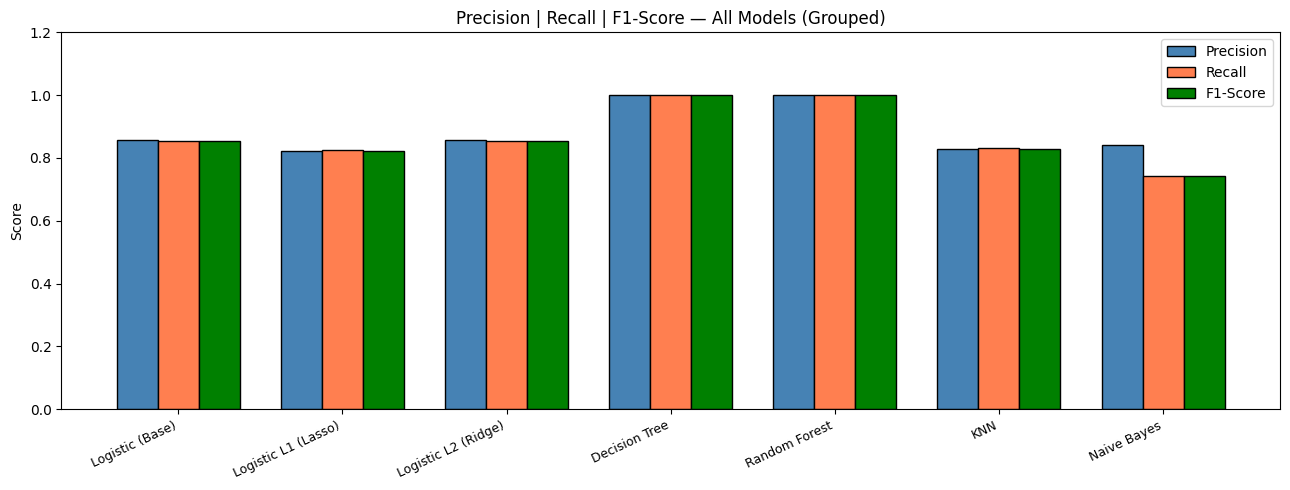

Saved: plot6_grouped_bar.png


In [ ]:

model_names = list(models.keys())
x = np.arange(len(model_names))
w = 0.25

plt.figure(figsize=(13, 5))
plt.bar(x - w, [precision_scores[n] for n in model_names], w,
        label='Precision', color='steelblue', edgecolor='black')
plt.bar(x,     [recall_scores[n]    for n in model_names], w,
        label='Recall',    color='coral',     edgecolor='black')
plt.bar(x + w, [f1_scores[n]        for n in model_names], w,
        label='F1-Score',  color='green',     edgecolor='black')
plt.xticks(x, model_names, rotation=25, ha='right', fontsize=9)
plt.ylabel('Score')
plt.ylim(0, 1.2)
plt.title('Precision | Recall | F1-Score — All Models (Grouped)')
plt.legend()
plt.tight_layout()
plt.savefig('plot6_grouped_bar.png')
plt.show()
print("Saved: plot6_grouped_bar.png")

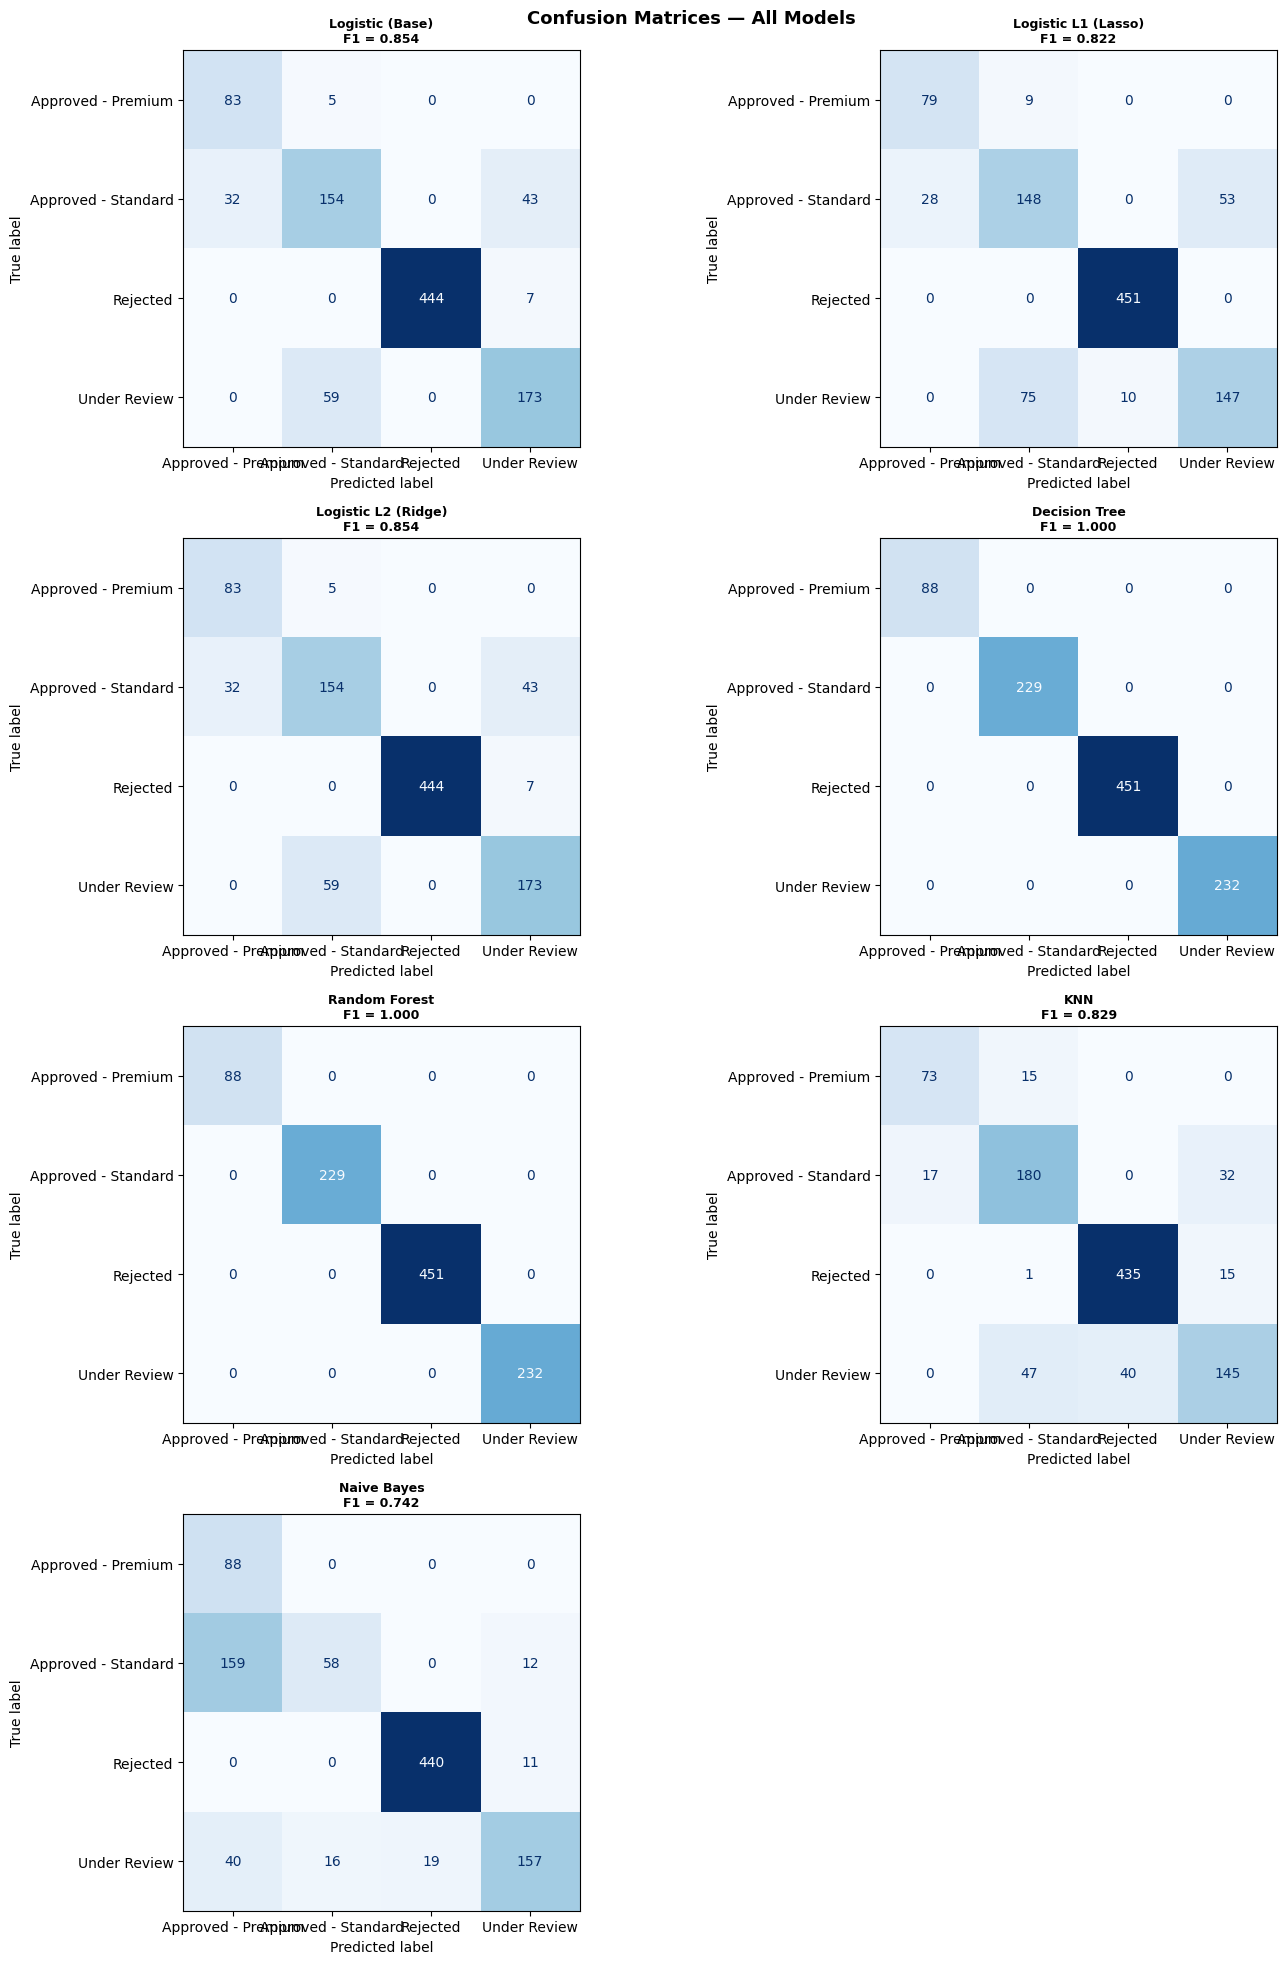

Saved: plot7_confusion_matrices.png


In [ ]:

# Adjust subplot grid based on number of models
fig, axes = plt.subplots(n // 2 + n % 2, 2, figsize=(15, 5 * (n // 2 + n % 2)))
axes = axes.flatten()

for idx, (name, pred) in enumerate(all_preds.items()):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=original_class_names) # Use original class names
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nF1 = {f1_scores[name]:.3f}',
                        fontsize=9, fontweight='bold')

# Hide unused subplots
for idx in range(n, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_confusion_matrices.png')
plt.show()
print("Saved: plot7_confusion_matrices.png")


Plotting Multiclass ROC Curves (One-vs-Rest per Model)...


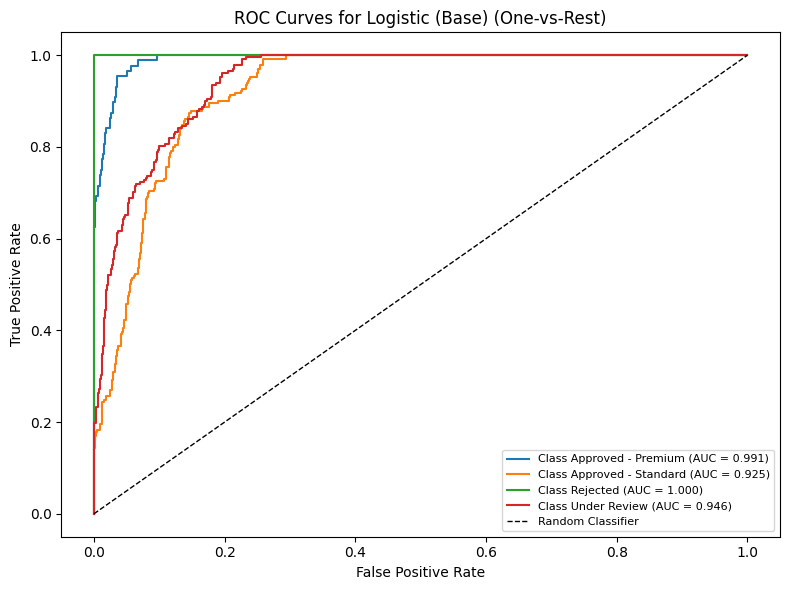

Saved: plot8_roc_curves_Logistic_(Base).png


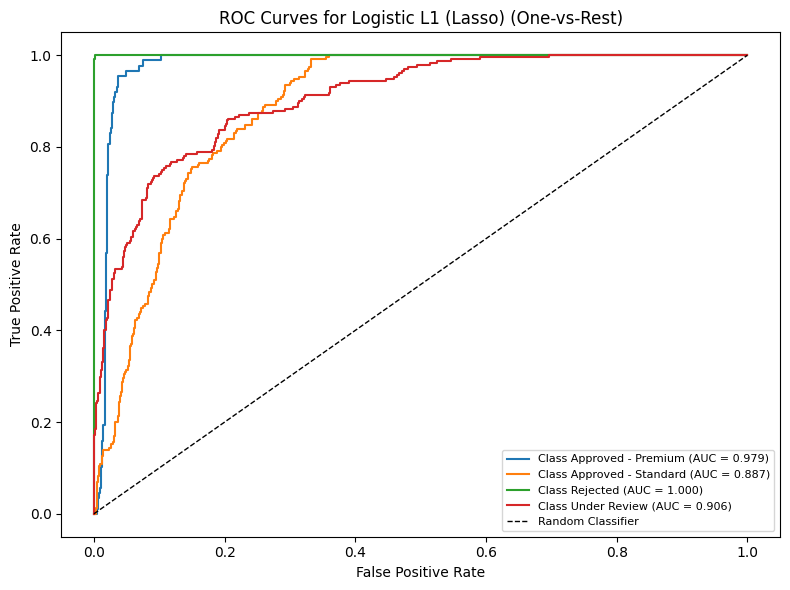

Saved: plot8_roc_curves_Logistic_L1_(Lasso).png


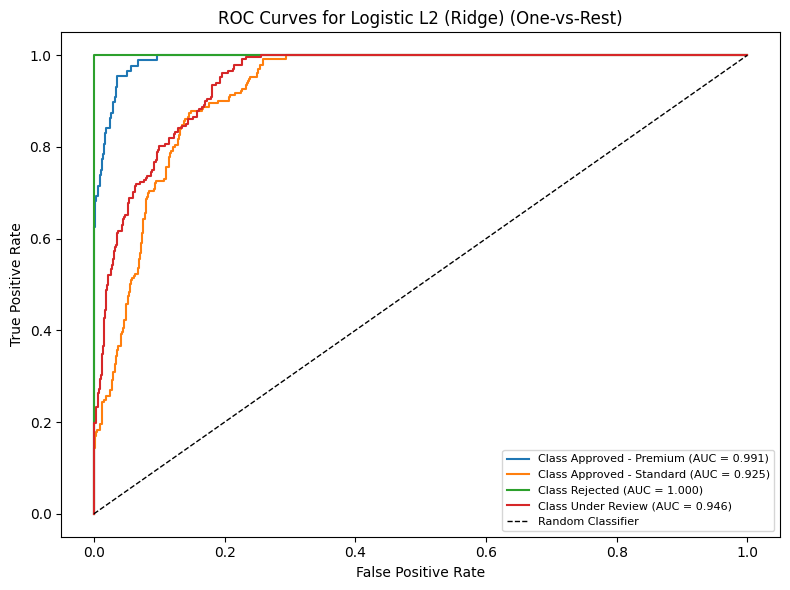

Saved: plot8_roc_curves_Logistic_L2_(Ridge).png


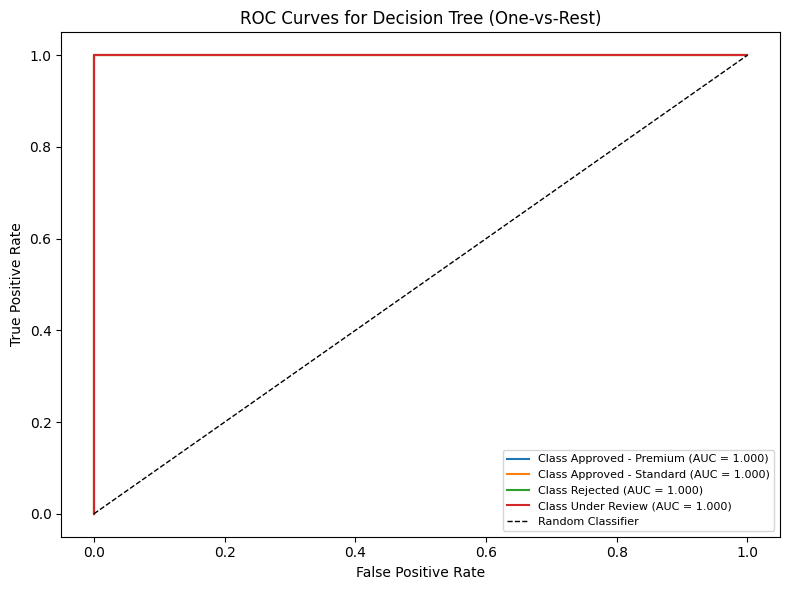

Saved: plot8_roc_curves_Decision_Tree.png


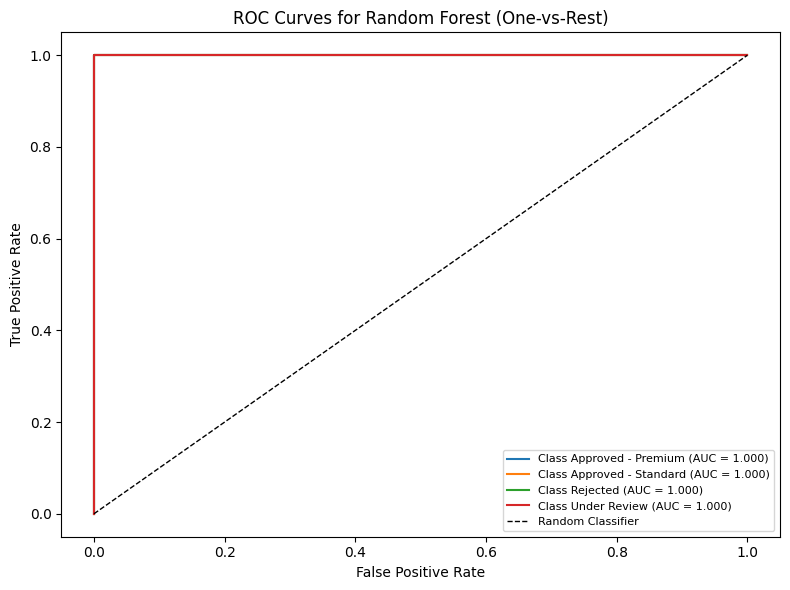

Saved: plot8_roc_curves_Random_Forest.png


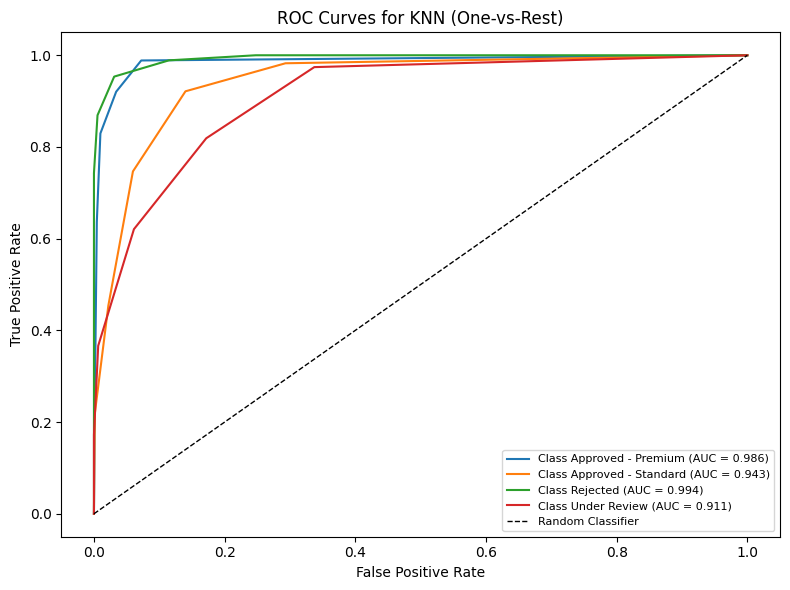

Saved: plot8_roc_curves_KNN.png


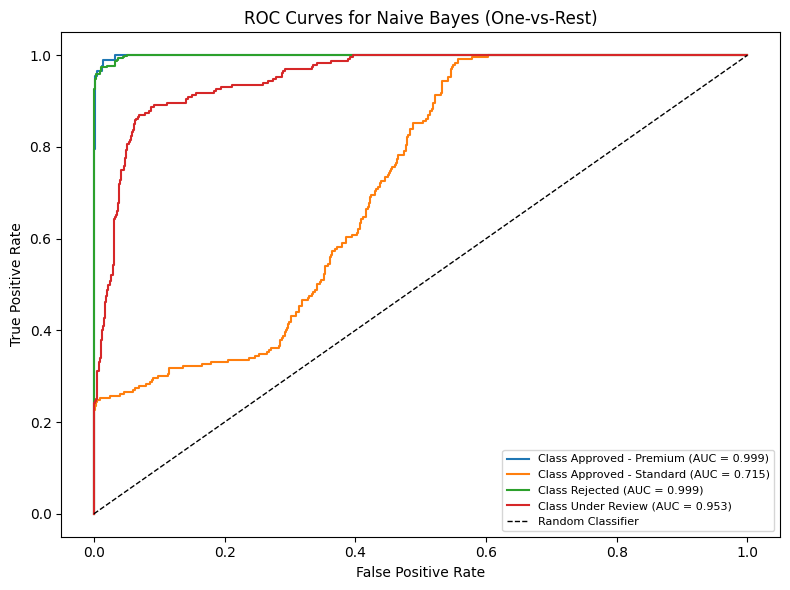

Saved: plot8_roc_curves_Naive_Bayes.png


In [ ]:

n_classes = len(original_class_names)

if n_classes > 2: # Multiclass ROC (One-vs-Rest)
    print("Plotting Multiclass ROC Curves (One-vs-Rest per Model)...")
    # Create a separate figure for each model to avoid clutter
    for model_name, probas in all_probas.items():
        plt.figure(figsize=(8, 6))
        for i, class_name in enumerate(original_class_names):
            # Binarize the true labels for the current class (one-vs-rest)
            y_test_binarized = (y_test == i).astype(int)
            # Get the probability for the current class
            y_proba_class = probas[:, i]

            fpr, tpr, _ = roc_curve(y_test_binarized, y_proba_class)
            auc_score = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_name} (AUC = {auc_score:.3f})')

        plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curves for {model_name} (One-vs-Rest)')
        plt.legend(loc='lower right', fontsize=8)
        plt.tight_layout()
        plt.savefig(f'plot8_roc_curves_{model_name.replace(" ", "_")}.png')
        plt.show()
        print(f"Saved: plot8_roc_curves_{model_name.replace(" ", "_")}.png")

else: # Binary ROC Curve (using weighted AUC from step 6)
    print("Plotting Binary ROC Curves...")
    plt.figure(figsize=(9, 6))
    colors_roc = plt.cm.tab10(np.linspace(0, 1, len(models)))

    for (name, proba_array), clr in zip(all_probas.items(), colors_roc):
        # For binary, proba_array is typically 2 columns, take probability of positive class (index 1)
        if proba_array.shape[1] > 1:
            proba = proba_array[:, 1]
        else:
            proba = proba_array.flatten() # if it's a single column for binary

        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr,
                 label=f'{name}  (AUC = {auc_scores[name]:.3f})', # Use the overall weighted AUC
                 color=clr, linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — All Models')
    plt.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig('plot8_roc_curves.png')
    plt.show()
    print("Saved: plot8_roc_curves.png")


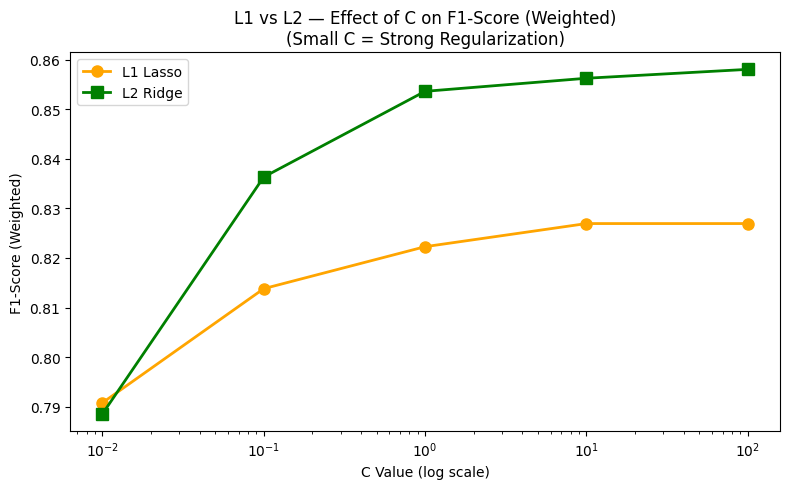

Saved: plot9_l1_vs_l2.png


In [ ]:

C_vals = [0.01, 0.1, 1, 10, 100]
l1_f1  = []
l2_f1  = []

# Determine the number of classes for multiclass metrics
n_classes = len(original_class_names)

for c in C_vals:
    m1 = LogisticRegression(penalty='l1', C=c, solver='liblinear',
                            max_iter=1000, random_state=42,
                            class_weight='balanced')
    m2 = LogisticRegression(penalty='l2', C=c, solver='lbfgs',
                            max_iter=1000, random_state=42,
                            class_weight='balanced')
    m1.fit(X_train, y_train)
    m2.fit(X_train, y_train)

    # Use weighted F1-score for multiclass comparison
    l1_f1.append(f1_score(y_test, m1.predict(X_test), average='weighted', zero_division=0))
    l2_f1.append(f1_score(y_test, m2.predict(X_test), average='weighted', zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(C_vals, l1_f1, 'o-', label='L1 Lasso', color='orange', linewidth=2, markersize=8)
plt.plot(C_vals, l2_f1, 's-', label='L2 Ridge',  color='green',  linewidth=2, markersize=8)
plt.xscale('log')
plt.title('L1 vs L2 — Effect of C on F1-Score (Weighted)\n(Small C = Strong Regularization)')
plt.xlabel('C Value (log scale)')
plt.ylabel('F1-Score (Weighted)')
plt.legend()
plt.tight_layout()
plt.savefig('plot9_l1_vs_l2.png')
plt.show()
print("Saved: plot9_l1_vs_l2.png")


In [ ]:
# ── STEP 13: FINAL SUMMARY ──────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS — Ranked by F1-Score")
print("=" * 60)
print(f"{'Rank':<5} {'Model':<22} {'Precision':>10}  "\
      f"{'Recall':>8}  {'F1':>8}  {'AUC':>8}")
print("-" * 60)

sorted_models = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)

for rank, (name, f1) in enumerate(sorted_models, 1):
    tag = "  BEST"  if rank == 1 else "  WORST" if rank == len(models) else ""
    print(f"{rank:<5} {name:<22} {precision_scores[name]:>10.4f}  "\
          f"{recall_scores[name]:>8.4f}  {f1:>8.4f}  "\
          f"{auc_scores[name]:>8.4f}{tag}")

best = sorted_models[0][0]
print(f"\nBest Model : {best}")
print(f"F1-Score   : {f1_scores[best]:.4f}")
print(f"ROC-AUC    : {auc_scores[best]:.4f}")
print(f"Precision  : {precision_scores[best]:.4f}")
print(f"Recall     : {recall_scores[best]:.4f}")
print("\nAnalysis Complete.")


  FINAL RESULTS — Ranked by F1-Score
Rank  Model                   Precision    Recall        F1       AUC
------------------------------------------------------------
1     Decision Tree              1.0000    1.0000    1.0000    1.0000  BEST
2     Random Forest              1.0000    1.0000    1.0000    1.0000
3     Logistic (Base)            0.8563    0.8540    0.8536    0.9696
4     Logistic L2 (Ridge)        0.8563    0.8540    0.8536    0.9696
5     KNN                        0.8292    0.8330    0.8292    0.9621
6     Logistic L1 (Lasso)        0.8228    0.8250    0.8223    0.9506
7     Naive Bayes                0.8412    0.7430    0.7419    0.9232  WORST

Best Model : Decision Tree
F1-Score   : 1.0000
ROC-AUC    : 1.0000
Precision  : 1.0000
Recall     : 1.0000

Analysis Complete.


In [ ]:

import pickle

best_model_obj  = models[best]
model_filename  = 'best_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(best_model_obj, file)

print(f"Best model '{best}' saved to {model_filename}")

Best model 'Decision Tree' saved to best_model.pkl
